# Ejercicio1 - Busqueda de Alojamiento en Airbnb (Jupyter).

Supongamos que somos un agente de [Airbnb](http://www.airbnb.com) localizado en Lisboa, y tenemos que atender peticiones de varios clientes. Tenemos un archivo llamado `airbnb.csv` (en la carpeta data) donde tenemos información de todos los alojamientos de Airbnb en Lisboa.

In [17]:
import pandas as pd
df_airbnb = pd.read_csv("./data/airbnb.csv")

In [23]:
df_airbnb.head()

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
0,6499,14455,Entire home/apt,Belém,8,5.0,2,1.0,57.0
1,17031,66015,Entire home/apt,Alvalade,0,0.0,2,1.0,46.0
2,25659,107347,Entire home/apt,Santa Maria Maior,63,5.0,3,1.0,69.0
3,29248,125768,Entire home/apt,Santa Maria Maior,225,4.5,4,1.0,58.0
4,29396,126415,Entire home/apt,Santa Maria Maior,132,5.0,4,1.0,67.0


En concreto el dataset tiene las siguientes variables:
- room_id: el identificador de la propiedad
- host_id: el identificador del dueño de la propiedad
- room_type: tipo de propiedad (vivienda completa/(habitacion para compartir/habitación privada)
- neighborhood: el barrio de Lisboa
- reviews: El numero de opiniones
- overall_satisfaction: Puntuacion media del apartamento
- accommodates: El numero de personas que se pueden alojar en la propiedad
- bedrooms: El número de habitaciones
- price: El precio (en euros) por noche

## Ejercicios

### 1. Realizar Análisis Exploratorio de los datos

Sobre este apartado deberá explorar los datos como se vio en clase .. aplicar métodos shape, columns, etc

In [7]:
# Número de filas y columnas
df_airbnb.shape

(13232, 9)

In [8]:
# Nombres de las columnas
df_airbnb.columns

Index(['room_id', 'host_id', 'room_type', 'neighborhood', 'reviews',
       'overall_satisfaction', 'accommodates', 'bedrooms', 'price'],
      dtype='object')

In [9]:
# Tipos de datos
df_airbnb.dtypes

room_id                   int64
host_id                   int64
room_type                object
neighborhood             object
reviews                   int64
overall_satisfaction    float64
accommodates              int64
bedrooms                float64
price                   float64
dtype: object

In [ ]:
# Los primertos 5 resultados contenidos en el dataframe
df_airbnb.head()

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
0,6499,14455,Entire home/apt,Belém,8,5.0,2,1.0,57.0
1,17031,66015,Entire home/apt,Alvalade,0,0.0,2,1.0,46.0
2,25659,107347,Entire home/apt,Santa Maria Maior,63,5.0,3,1.0,69.0
3,29248,125768,Entire home/apt,Santa Maria Maior,225,4.5,4,1.0,58.0
4,29396,126415,Entire home/apt,Santa Maria Maior,132,5.0,4,1.0,67.0


In [ ]:
# Los ultimos 5 resultados contenidos en el dataframe
df_airbnb.tail()

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
13227,19388006,135915593,Entire home/apt,São Vicente,0,0.0,6,3.0,415.0
13228,19393935,5376796,Entire home/apt,Santa Maria Maior,0,0.0,3,1.0,50.0
13229,19396300,6115933,Entire home/apt,Santo António,0,0.0,6,4.0,138.0
13230,19397373,97139334,Entire home/apt,São Vicente,0,0.0,4,1.0,56.0
13231,19400722,28219108,Entire home/apt,Areeiro,0,0.0,5,3.0,75.0


In [12]:
df_airbnb.describe()

,room_id,host_id,reviews,overall_satisfaction,accommodates,bedrooms,price
count,1.323200e+04,1.323200e+04,13232.000000,13222.000000,13232.000000,13232.000000,13232.000000
mean,1.055081e+07,3.616444e+07,29.130063,3.284677,3.917775,1.549501,86.592352
std,6.069884e+06,3.706975e+07,42.802762,2.123236,2.293757,1.062821,135.208926
min,6.499000e+03,1.445500e+04,0.000000,0.000000,1.000000,0.000000,10.000000
25%,5.054848e+06,6.197930e+06,2.000000,0.000000,2.000000,1.000000,45.000000
50%,1.166226e+07,2.207571e+07,11.000000,4.500000,4.000000,1.000000,64.000000
75%,1.609631e+07,5.546697e+07,39.000000,5.000000,5.000000,2.000000,93.000000
max,1.940072e+07,1.359156e+08,438.000000,5.000000,16.000000,10.000000,7496.000000


### 2. Realizar Filtrados a Datos

- Realizar filtrados, según sea el caso. 


Nota: 
Para obtener el top de un conjunto de datos debemos aplicar un head(n) además de ordenar los datos

#### Caso 1.

Alicia va a ir a Lisboa durante una semana con su marido y sus 2 hijos. Están buscando un apartamento con habitaciones separadas para los padres y los hijos. No les importa donde alojarse o el precio, simplemente quieren tener una experiencia agradable. Esto significa que solo aceptan lugares con más de 10 críticas con una puntuación mayor de 4. Cuando seleccionemos habitaciones para Alicia, tenemos que asegurarnos de ordenar las habitaciones de mejor a peor puntuación. Para aquellas habitaciones que tienen la misma puntuación, debemos mostrar antes aquellas con más críticas. Debemos darle 3 alternativas.

In [ ]:
import pandas as pd
df_airbnb = pd.read_csv("./data/airbnb.csv")

# Filtrar: propiedades con más de 10 críticas y puntuación mayor a 4, y al menos 2 habitaciones 
# Condición:
filtro = (df_airbnb["reviews"] > 10) & (df_airbnb["overall_satisfaction"] > 4) & (df_airbnb["bedrooms"] >= 2)

# Aplicar filtro y ordenar por satisfacción y número de críticas
df_filtrado = df_airbnb[filtro].sort_values(by=["overall_satisfaction", "reviews"], ascending=[False, False])

df_filtrado = df_filtrado.reset_index(drop=True)
df_filtrado.head(3)

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
0,176153,842219,Entire home/apt,Misericórdia,438,5.0,4,2.0,102.0
1,44043,192830,Entire home/apt,Santa Maria Maior,316,5.0,7,3.0,80.0
2,202150,989393,Entire home/apt,Santa Maria Maior,274,5.0,4,2.0,62.0


#### Caso 2

Roberto es un casero que tiene una casa en Airbnb. De vez en cuando nos llama preguntando sobre cuales son las críticas de su alojamiento. Hoy está particularmente enfadado, ya que su hermana Clara ha puesto una casa en Airbnb y Roberto quiere asegurarse de que su casa tiene más críticas que las de Clara. Tenemos que crear un dataframe con las propiedades de ambos. Las id de las casas de Roberto y Clara son 97503 y 90387  respectivamente. Finalmente guardamos este dataframe como excel llamado "roberto.xls

In [39]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import os

# Crear carpeta de salida
os.makedirs("./output", exist_ok=True)

# Cargar el archivo CSV con los datos
df_airbnb = pd.read_csv("./data/airbnb.csv")

# Filtrar por las room_id de Roberto (97503) y Clara (90387)
ids = [97503, 90387]
df_roberto_clara = df_airbnb[df_airbnb["room_id"].isin(ids)]

df_roberto_clara = df_roberto_clara.reset_index(drop=True)

# Guardar en archivo Excel
output_path = './output/roberto_clara.xlsx'
df_roberto_clara.to_excel(output_path, index=False, sheet_name='Comparación')

# Mostramos el dataframe
df_roberto_clara.head()


,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
0,90387,490050,Private room,Santo António,204,5.0,2,1.0,46.0
1,97503,515924,Private room,Santo António,39,4.0,2,1.0,26.0



#### Caso 3

Diana va a Lisboa a pasar 3 noches y quiere conocer a gente nueva. Tiene un presupuesto de 50€ para su alojamiento. Debemos buscarle las 10 propiedades más baratas, dandole preferencia a aquellas que sean habitaciones compartidas *(room_type == Shared room)*, y para aquellas viviendas compartidas debemos elegir aquellas con mejor puntuación.

In [40]:
import pandas as pd

# Cargar el dataset
df_airbnb = pd.read_csv("./data/airbnb.csv")

# Filtrar propiedades con precio <= 50 y que permitan al menos 1 persona
filtro_presupuesto = df_airbnb["price"] <= 50
df_filtrado = df_airbnb[filtro_presupuesto]

# Separar en habitaciones compartidas y el resto
df_shared = df_filtrado[df_filtrado["room_type"] == "Shared room"]
df_otros = df_filtrado[df_filtrado["room_type"] != "Shared room"]

# Ordenar compartidas por puntuación (mayor es mejor), luego por precio
df_shared_ordenado = df_shared.sort_values(by=["overall_satisfaction", "price"], ascending=[False, True])

# Ordenar otros solo por precio (ya que no se da preferencia en puntuación)
df_otros_ordenado = df_otros.sort_values(by="price")

# Unir ambos (prioridad a compartidas)
df_final = pd.concat([df_shared_ordenado, df_otros_ordenado])

# Seleccionar las 10 primeras opciones
df_diana = df_final.head(10)

df_diana = df_diana.reset_index(drop=True)

# Mostrar resultado
df_diana[["room_id", "room_type", "price", "overall_satisfaction"]].head(10)


,room_id,room_type,price,overall_satisfaction
0,14933182,Shared room,11.0,5.0
1,10397682,Shared room,13.0,5.0
2,12299998,Shared room,13.0,5.0
3,12305540,Shared room,13.0,5.0
4,14719962,Shared room,13.0,5.0
5,12268067,Shared room,16.0,5.0
6,16150682,Shared room,16.0,5.0
7,17096560,Shared room,16.0,5.0
8,11427995,Shared room,18.0,5.0
9,17497074,Shared room,18.0,5.0


### 3. Realizar Agrupamientos de Datos


- Según su criterio, aplicar 2 tipos de agrupamientos a los datos brindados. 
- **Opcional**, averiguar como realizar el gráfico de los 2 agrupamientos de los datos realizados. Se podría emplear librerias como mathplot y searbon ... ayudarse de chatgtp, etc


In [49]:
agrupamiento_1 = df_airbnb.groupby("room_type")[["price", "overall_satisfaction"]].mean().reset_index()
agrupamiento_1.head()

,room_type,price,overall_satisfaction
0,Entire home/apt,101.338181,3.529526
1,Private room,45.629967,2.604034
2,Shared room,34.397661,2.441520


In [45]:
agrupamiento_2 = df_airbnb.groupby("neighborhood").agg({
    "room_id": "count",
    "overall_satisfaction": "mean"
}).rename(columns={"room_id": "num_propiedades"}).reset_index()

agrupamiento_2.head()


,neighborhood,num_propiedades,overall_satisfaction
0,Ajuda,108,3.722222
1,Alcântara,213,2.798122
2,Alvalade,253,2.648221
3,Areeiro,280,2.360714
4,Arroios,1664,3.057797


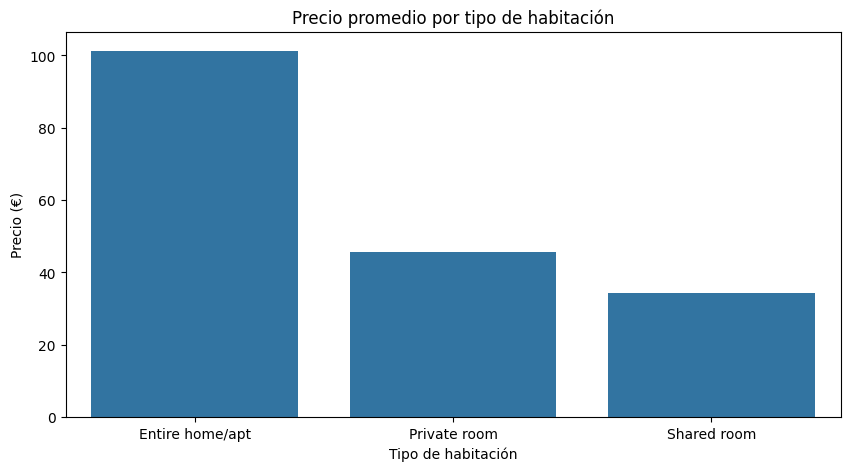

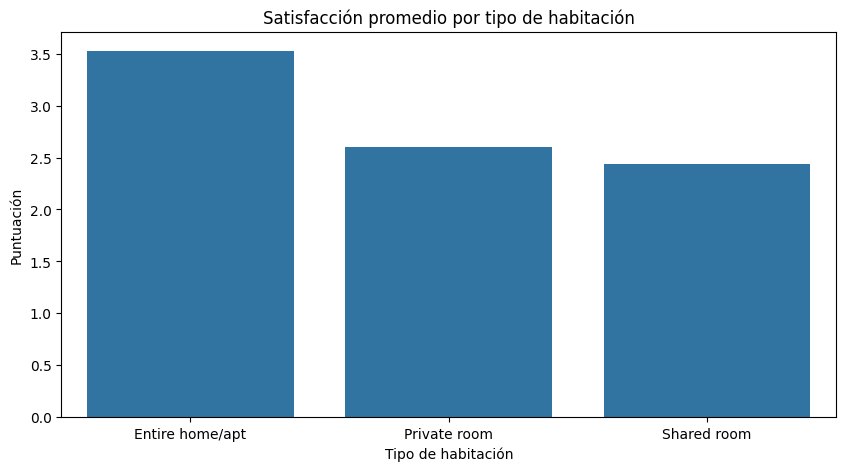

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(data=agrupamiento_1, x="room_type", y="price")
plt.title("Precio promedio por tipo de habitación")
plt.ylabel("Precio (€)")
plt.xlabel("Tipo de habitación")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=agrupamiento_1, x="room_type", y="overall_satisfaction")
plt.title("Satisfacción promedio por tipo de habitación")
plt.ylabel("Puntuación")
plt.xlabel("Tipo de habitación")
plt.show()
